# Exploracion de TIGR2000

Este notebook carga y explora los datos exportados en `data/npy` y `data/csv`.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base = Path('data')
csv_dir = base / 'csv'
npy_dir = base / 'npy'

print('CSV dir:', csv_dir.resolve())
print('NPY dir:', npy_dir.resolve())

CSV dir: C:\Users\PC\Documents\GitHub\GPT\data\TIGR\data\csv
NPY dir: C:\Users\PC\Documents\GitHub\GPT\data\TIGR\data\npy


In [5]:
# Cargar arrays NPY
pressures = np.load(npy_dir / 'pressures.npy')
temperature = np.load(npy_dir / 'temperature.npy')
humidity = np.load(npy_dir / 'humidity.npy')
ozone = np.load(npy_dir / 'ozone.npy')
ts = np.load(npy_dir / 'ts.npy')
ps = np.load(npy_dir / 'ps.npy')

# Cargar CSV
metadata = pd.read_csv(csv_dir / 'metadata.csv')
wide = pd.read_csv(csv_dir / 'tigr_wide.csv')

print('Shapes NPY:')
print('  pressures:', pressures.shape)
print('  temperature:', temperature.shape)
print('  humidity:', humidity.shape)
print('  ozone:', ozone.shape)
print('  ts:', ts.shape)
print('  ps:', ps.shape)
print('')
print('Shapes CSV:')
print('  metadata:', metadata.shape)
print('  tigr_wide:', wide.shape)

Shapes NPY:
  pressures: (43,)
  temperature: (2311, 43)
  humidity: (2311, 43)
  ozone: (2311, 43)
  ts: (2311,)
  ps: (2311,)

Shapes CSV:
  metadata: (2311, 4)
  tigr_wide: (2311, 136)


In [6]:
# Vista rapida de metadatos
metadata.head()

,latitude,longitude,ific,date
0,19.27,-166.65,1,790400
1,1.34,-172.92,2,790500
2,8.36,-79.15,3,820100
3,29.22,-82.17,4,820100
4,23.39,99.92,5,820100


In [7]:
wide.head()

,profile_id,latitude,longitude,ific,date,ts_K,ps_mb,T_L00_0.0026mb,H2O_L00,O3_L00,...,O3_L39,T_L40_900mb,H2O_L40,O3_L40,T_L41_955mb,H2O_L41,O3_L41,T_L42_1.01e+03mb,H2O_L42,O3_L42
0,0,19.27,-166.65,1,790400,296.86,1013.0,197.78,1.876600e-07,0.000002,...,8.263000e-08,293.38,0.011030,7.769900e-08,295.30,0.012630,6.451100e-08,296.86,0.013820,1.619600e-08
1,1,1.34,-172.92,2,790500,299.61,1013.0,193.56,1.891800e-07,0.000002,...,7.057800e-08,295.16,0.013584,6.274800e-08,297.56,0.015665,4.701400e-08,299.61,0.017152,4.792500e-09
2,2,8.36,-79.15,3,820100,296.92,1013.0,203.75,1.884600e-07,0.000002,...,7.964000e-08,292.71,0.012654,7.863100e-08,296.03,0.014138,7.333700e-08,296.92,0.016184,1.589300e-08
3,3,29.22,-82.17,4,820100,292.73,1013.0,207.57,1.885800e-07,0.000001,...,6.626800e-08,288.47,0.008148,5.440700e-08,290.79,0.010253,4.033400e-08,292.73,0.012082,2.199100e-08
4,4,23.39,99.92,5,820100,286.81,1013.0,205.14,1.884500e-07,0.000001,...,3.333600e-08,284.68,0.007467,2.516300e-08,285.90,0.007035,2.516300e-08,286.81,0.006703,2.516300e-08


In [10]:
# Estadisticas basicas
print('Temperatura (K)')
print('  min:', float(np.min(temperature)))
print('  mean:', float(np.mean(temperature)))
print('  max:', float(np.max(temperature)))
print('')
print('Humedad (g/kg)')
print('  min:', float(np.min(humidity)))
print('  mean:', float(np.mean(humidity)))
print('  max:', float(np.max(humidity)))
print('')
print('Ozono (g/kg)')
print('  min:', float(np.min(ozone)))
print('  mean:', float(np.mean(ozone)))
print('  max:', float(np.max(ozone)))

Temperatura (K)
  min: 153.18
  mean: 235.8816744991094
  max: 314.16

Humedad (g/kg)
  min: 1.8332e-07
  mean: 0.0007944991826501164
  max: 0.029685

Ozono (g/kg)
  min: 2.6753e-09
  mean: 2.625266766248377e-06
  max: 1.7701e-05


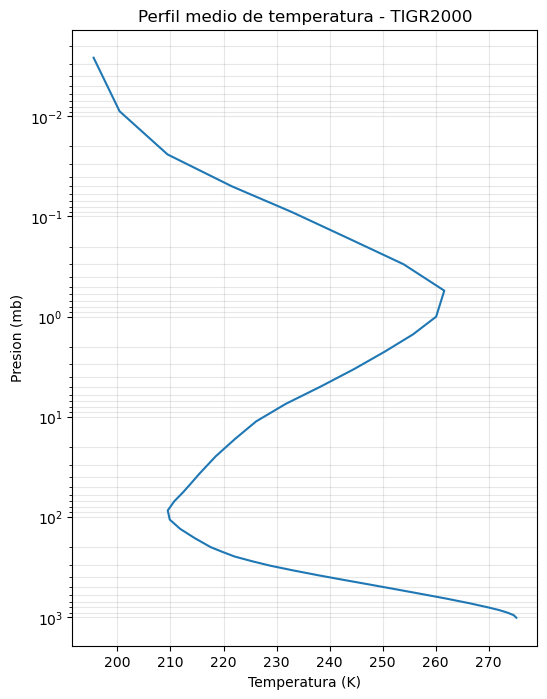

In [29]:
# Perfil de temperatura promedio vs presion
temp_mean_profile = temperature.mean(axis=0)

plt.figure(figsize=(6, 8))
plt.semilogy(temp_mean_profile, pressures)
plt.gca().invert_yaxis()
plt.xlabel('Temperatura (K)')
plt.ylabel('Presion (mb)')
plt.title('Perfil medio de temperatura - TIGR2000')
plt.grid(True, which='both', alpha=0.3)
plt.show()

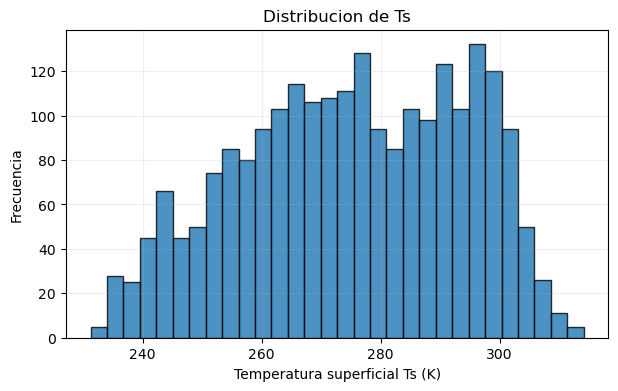

In [7]:
# Distribucion de temperatura superficial
plt.figure(figsize=(7, 4))
plt.hist(ts, bins=30, edgecolor='black', alpha=0.8)
plt.xlabel('Temperatura superficial Ts (K)')
plt.ylabel('Frecuencia')
plt.title('Distribucion de Ts')
plt.grid(alpha=0.2)
plt.show()

In [8]:
# Comprobacion de consistencia entre metadata y arrays
assert metadata.shape[0] == temperature.shape[0] == humidity.shape[0] == ozone.shape[0]
print('Consistencia OK: mismo numero de perfiles en CSV y NPY')

Consistencia OK: mismo numero de perfiles en CSV y NPY


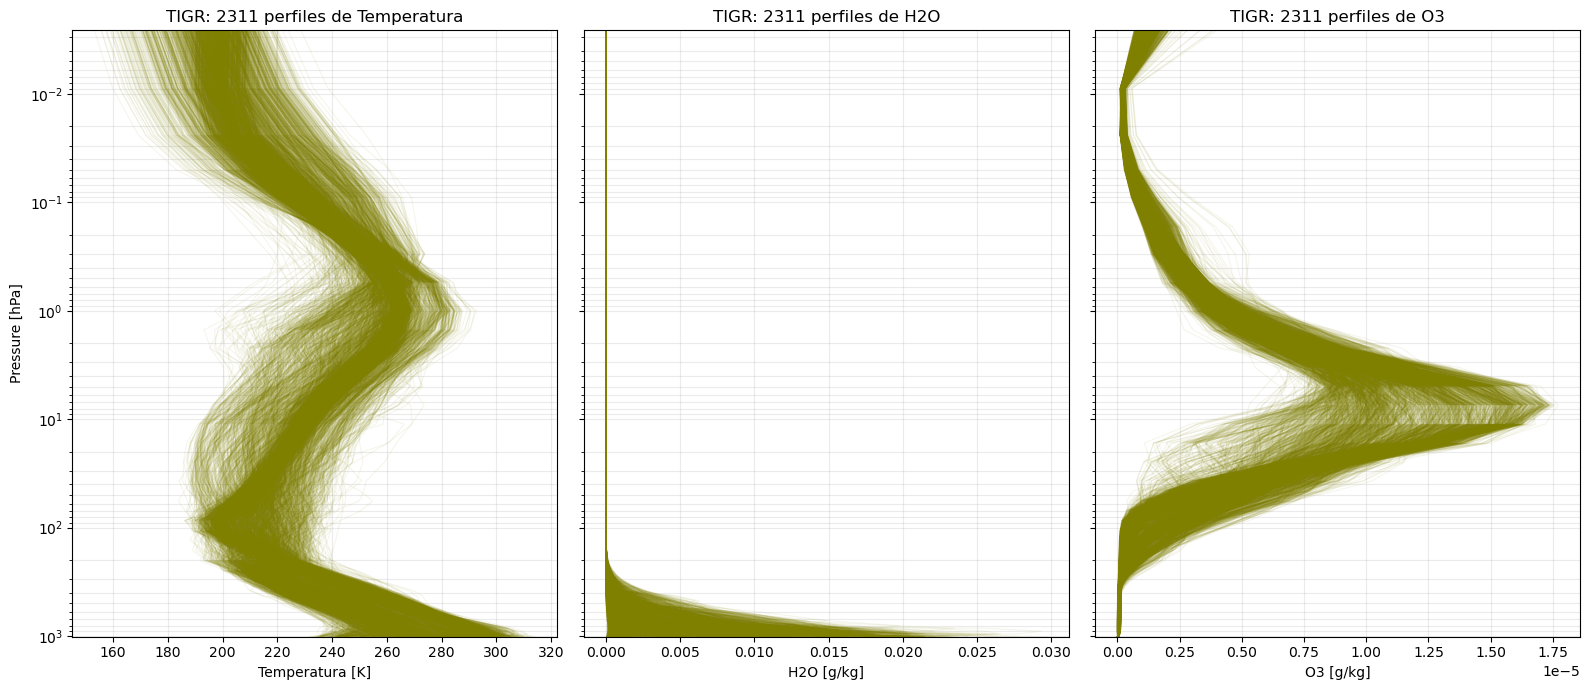

In [26]:
# 2311 perfiles TIGR en un solo plot (3 paneles): T, H2O y O3 (sin augmented)
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

for i in range(temperature.shape[0]):
    axes[0].plot(temperature[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[1].plot(humidity[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[2].plot(ozone[i, :], pressures, color='olive', alpha=0.08, lw=0.8)

axes[0].set_title('TIGR: 2311 perfiles de Temperatura')
axes[0].set_xlabel('Temperatura [K]')
axes[0].set_ylabel('Pressure [hPa]')

axes[1].set_title('TIGR: 2311 perfiles de H2O')
axes[1].set_xlabel('H2O [g/kg]')

axes[2].set_title('TIGR: 2311 perfiles de O3')
axes[2].set_xlabel('O3 [g/kg]')

for ax in axes:
    ax.set_yscale('log')
    ax.set_ylim(pressures.max(), pressures.min())
    ax.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:
q = np.clip(humidity, 0.0, None)
p_hpa_2d = np.broadcast_to(pressures.reshape(1, -1), q.shape)
p_hpa_2d.shape

(2311, 43)

In [16]:
pressures.shape

(43,)

In [18]:
# Filtrado cloud-free con umbral de RH = 96% (paper): conservar perfiles con RHmax < 96%
RH_THRESHOLD = 96.0

# humidity en TIGR se usa como fraccion de masa (kg/kg ~ g/g)
q = np.clip(humidity, 0.0, None)

# Presion 2D (hPa) para operar por perfil y nivel
p_hpa_2d = np.broadcast_to(pressures.reshape(1, -1), q.shape)

# Temperatura en Celsius para ecuacion de saturacion (Tetens)
t_c = temperature - 273.15
e_sat_hpa = 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))

# Presion de vapor real desde humedad especifica
e_hpa = (q * p_hpa_2d) / (0.622 + 0.378 * q)

# Humedad relativa (%)
rh = 100.0 * e_hpa / np.maximum(e_sat_hpa, 1e-8)
rh = np.clip(rh, 0.0, 500.0)

# Cloud-free: el perfil completo debe estar por debajo del umbral
rh_max_profile = np.nanmax(rh, axis=1)
mask_cf96 = rh_max_profile < RH_THRESHOLD
idx_cf96 = np.where(mask_cf96)[0]

# Arreglos filtrados unificados
temperature_cf96 = temperature[mask_cf96]
humidity_cf96 = humidity[mask_cf96]
ozone_cf96 = ozone[mask_cf96]
rh_cf96 = rh[mask_cf96]

# Guardar NPY unificados en data/npy
np.save(npy_dir / 'temperature_cf96.npy', temperature_cf96)
np.save(npy_dir / 'humidity_cf96.npy', humidity_cf96)
np.save(npy_dir / 'ozone_cf96.npy', ozone_cf96)
np.save(npy_dir / 'rh_cf96.npy', rh_cf96)
np.save(npy_dir / 'profile_index_cf96.npy', idx_cf96)

print(f'Threshold RH: {RH_THRESHOLD:.1f}%')
print(f'Perfiles originales: {temperature.shape[0]}')
print(f'Perfiles cloud-free (RHmax < 96%): {temperature_cf96.shape[0]}')
print('Archivos guardados en data/npy:')
print('  temperature_cf96.npy, humidity_cf96.npy, ozone_cf96.npy, rh_cf96.npy, profile_index_cf96.npy')

Threshold RH: 96.0%
Perfiles originales: 2311
Perfiles cloud-free (RHmax < 96%): 1743
Archivos guardados en data/npy:
  temperature_cf96.npy, humidity_cf96.npy, ozone_cf96.npy, rh_cf96.npy, profile_index_cf96.npy


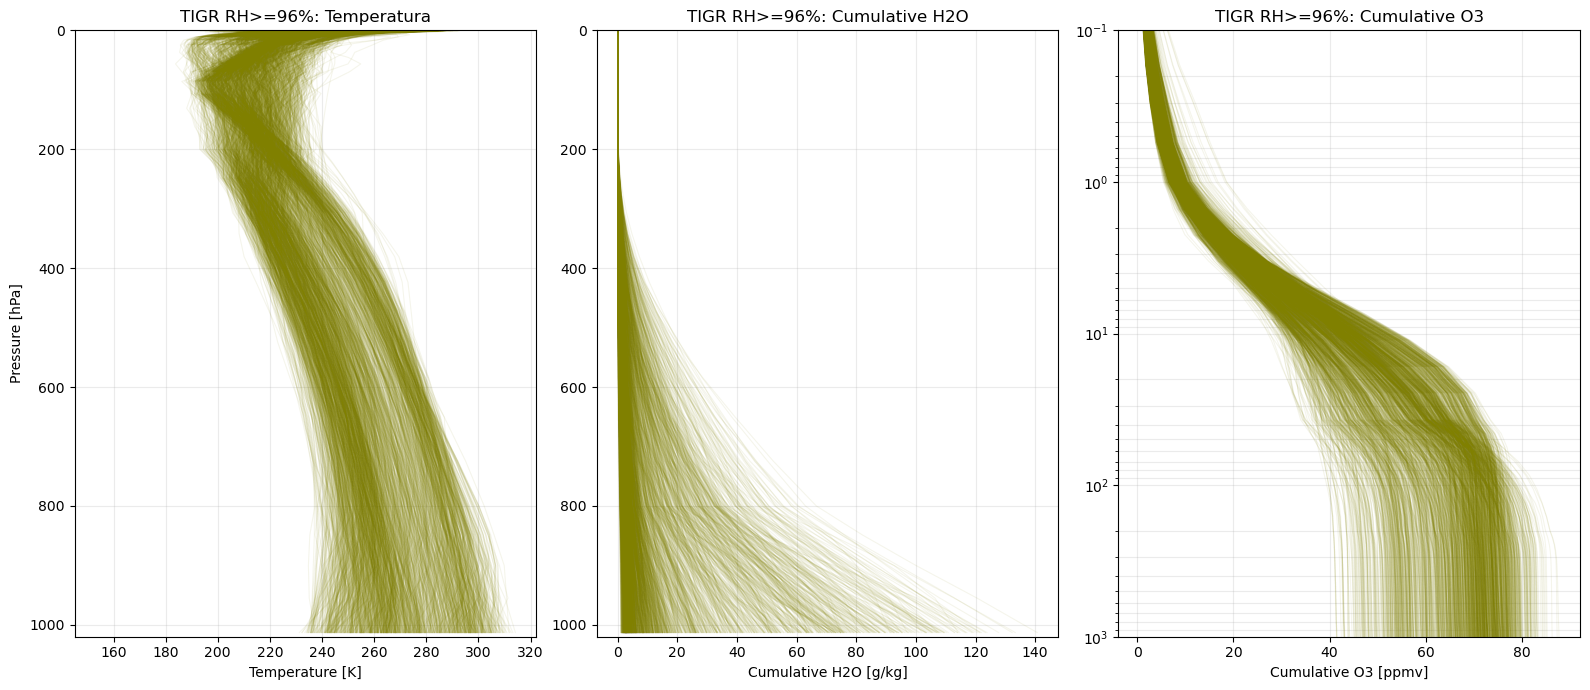

In [19]:
# Plot estilo referencia: temperatura, H2O acumulada y O3 acumulado (ppmv)
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

# Conversiones para ejes como la imagen
h2o_gkg_rh96 = humidity_cf96* 1000.0
h2o_cum_gkg = np.cumsum(h2o_gkg_rh96, axis=1)

# O3 de fraccion de masa (g/g) a ppmv: x_ppmv = w * (M_air/M_o3) * 1e6
M_AIR = 28.9647
M_O3 = 48.0
o3_ppmv_rh96 = ozone_cf96 * (M_AIR / M_O3) * 1e6
o3_cum_ppmv = np.cumsum(o3_ppmv_rh96, axis=1)

for i in range(temperature_cf96.shape[0]):
    axes[0].plot(temperature_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[1].plot(h2o_cum_gkg[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[2].plot(o3_cum_ppmv[i, :], pressures, color='olive', alpha=0.08, lw=0.8)

# Panel 1: Temperatura (escala lineal de presion, como referencia)
axes[0].set_title('TIGR RH>=96%: Temperatura')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Pressure [hPa]')
axes[0].set_ylim(1020, 0)
axes[0].grid(True, alpha=0.25)

# Panel 2: H2O acumulada (escala lineal de presion)
axes[1].set_title('TIGR RH>=96%: Cumulative H2O')
axes[1].set_xlabel('Cumulative H2O [g/kg]')
axes[1].set_ylim(1020, 0)
axes[1].grid(True, alpha=0.25)

# Panel 3: O3 acumulado en ppmv (escala log en presion y rango visible de referencia)
axes[2].set_title('TIGR RH>=96%: Cumulative O3')
axes[2].set_xlabel('Cumulative O3 [ppmv]')
axes[2].set_yscale('log')
axes[2].set_ylim(1e3, 1e-1)
axes[2].grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.show()

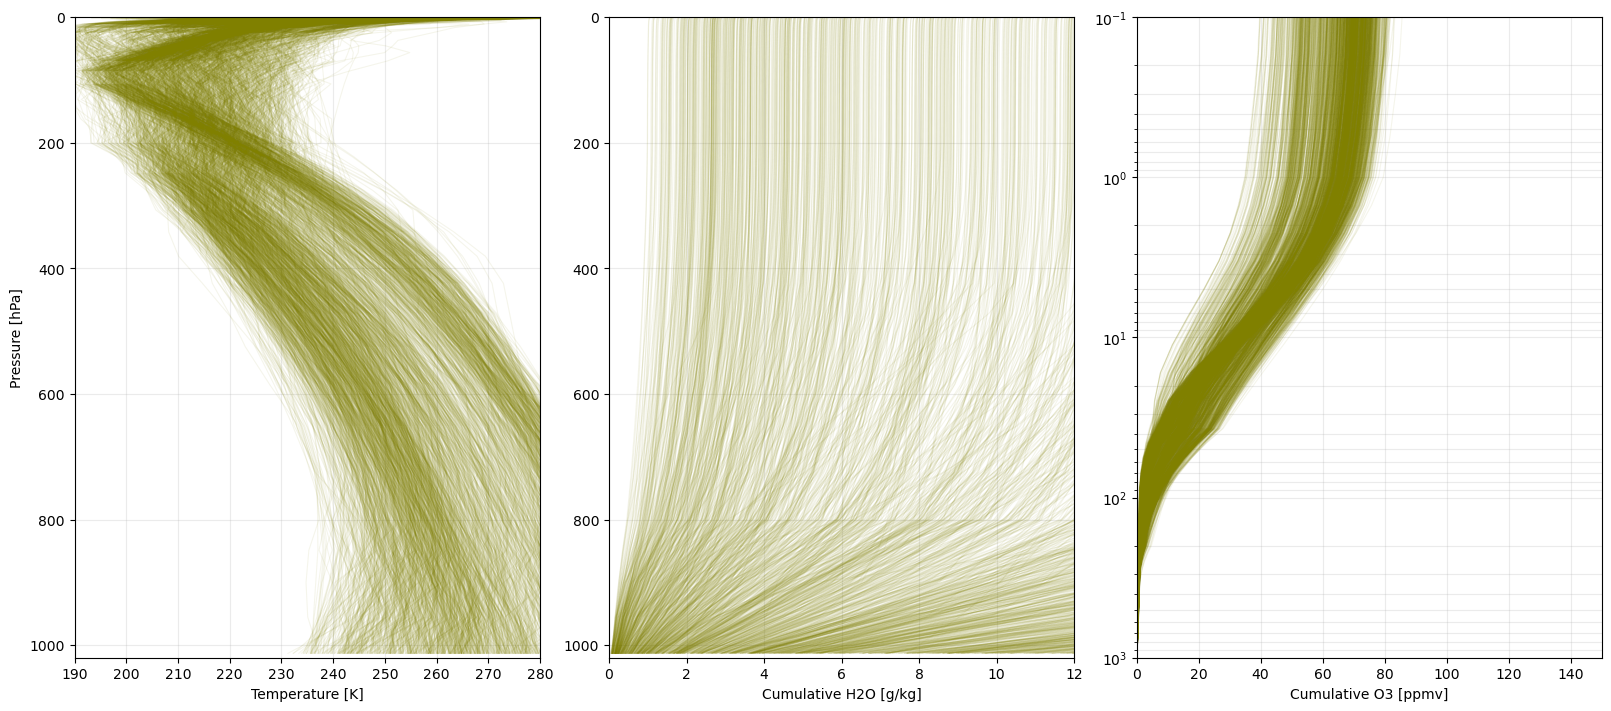

In [24]:
# Plot cloud-free (RHmax<96%) con ejes X como la referencia y acumulacion en sentido superficie->TOA
fig, axes = plt.subplots(1, 3, figsize=(16, 7), constrained_layout=True)

# Conversiones
h2o_gkg_cf96 = humidity_cf96 * 1000.0

M_AIR = 28.9647
M_O3 = 48.0
o3_ppmv_cf96 = ozone_cf96 * (M_AIR / M_O3) * 1e6

# Acumulacion en el sentido fisico superficie->arriba (corrige el efecto visual invertido)
h2o_cum_gkg_cf96 = np.cumsum(h2o_gkg_cf96[:, ::-1], axis=1)[:, ::-1]
o3_cum_ppmv_cf96 = np.cumsum(o3_ppmv_cf96[:, ::-1], axis=1)[:, ::-1]

for i in range(temperature_cf96.shape[0]):
    axes[0].plot(temperature_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[1].plot(h2o_cum_gkg_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[2].plot(o3_cum_ppmv_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)

# Temperatura (mismo rango X de referencia)
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Pressure [hPa]')
axes[0].set_xlim(190, 280)
axes[0].set_ylim(1020, 0)
axes[0].grid(True, alpha=0.25)

# H2O acumulada (mismo rango X de referencia)
axes[1].set_xlabel('Cumulative H2O [g/kg]')
axes[1].set_xlim(0, 12)
axes[1].set_ylim(1020, 0)
axes[1].grid(True, alpha=0.25)

# O3 acumulado en ppmv (mismo rango X de referencia)
axes[2].set_xlabel('Cumulative O3 [ppmv]')
axes[2].set_xlim(0, 150)
axes[2].set_yscale('log')
axes[2].set_ylim(1e3, 1e-1)
axes[2].grid(True, which='both', alpha=0.25)

plt.show()

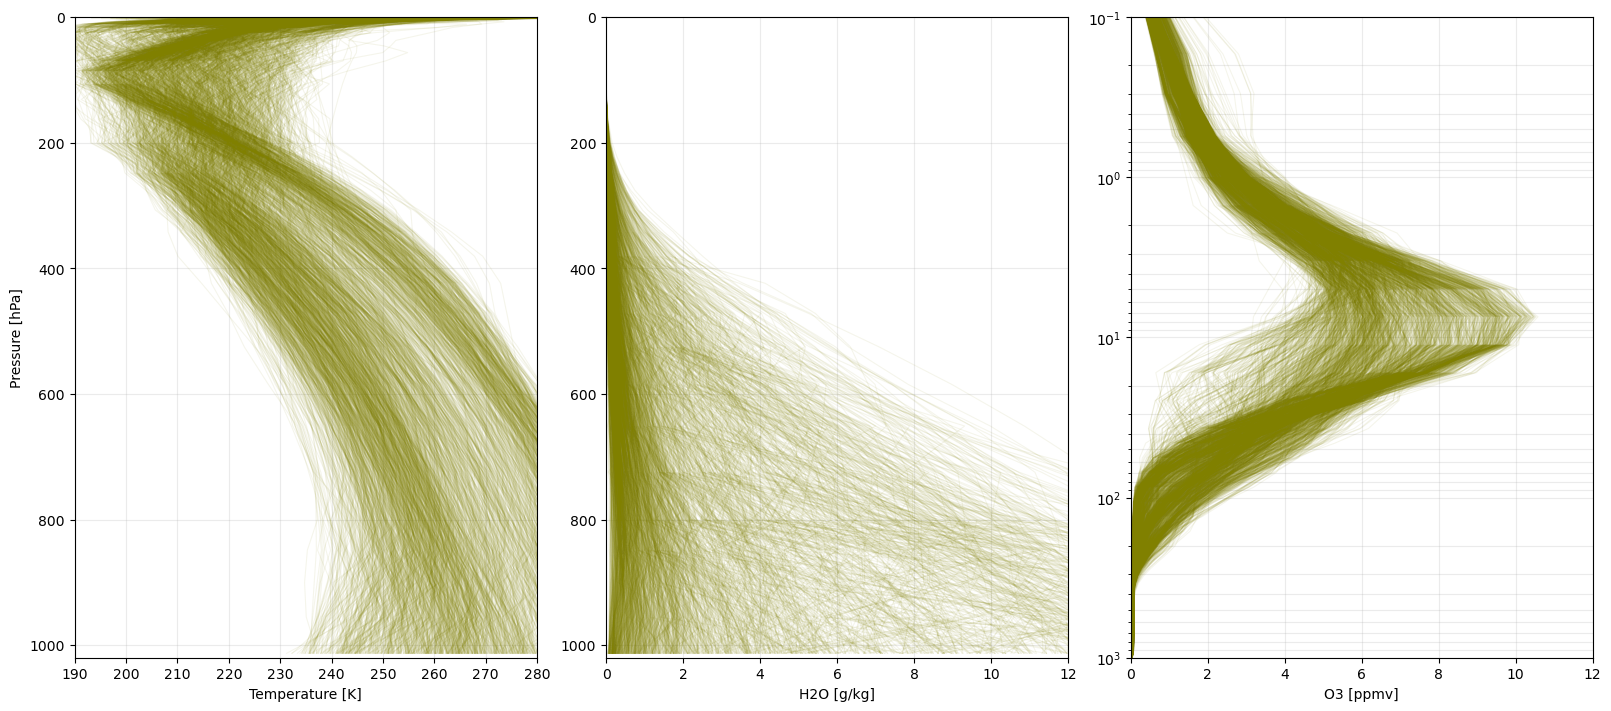

In [27]:
# Plot cloud-free (RHmax<96%) SIN acumulacion: valores puntuales por nivel
fig, axes = plt.subplots(1, 3, figsize=(16, 7), constrained_layout=True)

# Conversiones puntuales (sin cumsum)
h2o_gkg_point_cf96 = humidity_cf96 * 1000.0

M_AIR = 28.9647
M_O3 = 48.0
o3_ppmv_point_cf96 = ozone_cf96 * (M_AIR / M_O3) * 1e6

for i in range(temperature_cf96.shape[0]):
    axes[0].plot(temperature_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[1].plot(h2o_gkg_point_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)
    axes[2].plot(o3_ppmv_point_cf96[i, :], pressures, color='olive', alpha=0.08, lw=0.8)

# Temperatura
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Pressure [hPa]')
axes[0].set_xlim(190, 280)
axes[0].set_ylim(1020, 0)
axes[0].grid(True, alpha=0.25)

# H2O puntual
axes[1].set_xlabel('H2O [g/kg]')
axes[1].set_xlim(0, 12)
axes[1].set_ylim(1020, 0)
axes[1].grid(True, alpha=0.25)

# O3 puntual en ppmv
axes[2].set_xlabel('O3 [ppmv]')
axes[2].set_xlim(0, 12)
axes[2].set_yscale('log')
axes[2].set_ylim(1e3, 1e-1)
axes[2].grid(True, which='both', alpha=0.25)

plt.show()